# Madrid Housing Spatial Autocorrelation

**Spatial Statistics · Housing Analytics · Moran's I · K-Nearest Neighbors**

This project quantifies spatial autocorrelation in housing prices within Madrid's historical centre.

## Key result

Using row-standardized **8-nearest-neighbor** spatial weights:

- Raw-price Moran's I: **0.2766**
- Log-price Moran's I: **0.2961**
- Permutation p-value: **0.001**

The result indicates statistically significant positive spatial autocorrelation: nearby homes tend to have more similar prices than would be expected under spatial randomness.

## 1. Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors

## 2. Load data

The original coursework CSV is not redistributed publicly.  
Place `Data_Housing_Madrid.csv` in `data/` to reproduce the notebook.

In [2]:
data_path = Path("../data/Data_Housing_Madrid.csv")
df = pd.read_csv(data_path)

print("Full dataset:", df.shape)
df[["house.price", "historical", "longitude", "latitude"]].head()

Full dataset: (10512, 22)


,house.price,historical,longitude,latitude
0,3571.0,0,-3.656538,40.431302
1,3115.0,0,-3.721426,40.482340
2,2940.0,0,-3.647869,40.408970
3,2811.0,0,-3.754118,40.374849
4,3808.0,0,-3.670743,40.481328


## 3. Historical-centre selection

The academic objective specifically concerns Madrid's historical centre, so only `historical == 1` is used.

In [3]:
historical = df.loc[
    df["historical"] == 1,
    ["house.price", "longitude", "latitude"]
].copy()

for column in ["house.price", "longitude", "latitude"]:
    historical[column] = pd.to_numeric(historical[column], errors="coerce")

historical = historical.dropna()

historical = historical.loc[
    (historical["house.price"] > 0)
    & historical["longitude"].between(-180, 180)
    & historical["latitude"].between(-90, 90)
].copy()

print("Historical-centre properties:", len(historical))
historical.describe()

Historical-centre properties: 3633


,house.price,longitude,latitude
count,3633.000000,3633.000000,3633.000000
mean,4646.738904,-3.688349,40.423055
std,1328.530289,0.017074,0.021550
min,908.000000,-3.775181,40.344647
25%,3804.000000,-3.701696,40.406667
50%,4444.000000,-3.689303,40.421844
75%,5200.000000,-3.673911,40.436822
max,20131.000000,-3.567274,40.509145


## 4. Price distribution

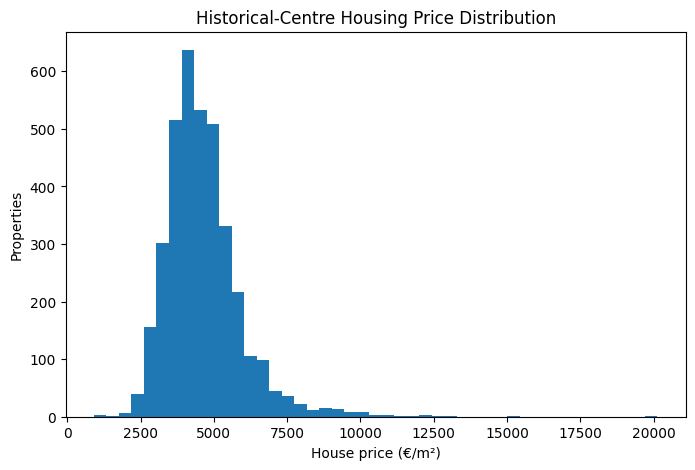

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(historical["house.price"], bins=45)
plt.xlabel("House price (€/m²)")
plt.ylabel("Properties")
plt.title("Historical-Centre Housing Price Distribution")
plt.show()

Prices are right-skewed, so the analysis reports Moran's I for both the raw price and the logarithm of price.

## 5. Spatial weights

In [5]:
coordinates = np.radians(
    historical[["latitude", "longitude"]].to_numpy(float)
)

def knn_indices(coordinates, k):
    nn = NearestNeighbors(
        n_neighbors=k + 1,
        metric="haversine",
        algorithm="ball_tree",
    )
    nn.fit(coordinates)
    distances, indices = nn.kneighbors(coordinates)
    return indices[:, 1:], distances[:, 1:]

neighbors8, distances8 = knn_indices(coordinates, 8)

print(
    "Mean neighbor distance (km):",
    round(float(distances8.mean() * 6371.0088), 4)
)

Mean neighbor distance (km): 0.1306


Equal weights are assigned to the eight nearest properties. Because every row has eight neighbors, the weights are row-standardized as `1/8`.

## 6. Global Moran's I

In [6]:
def moran_i(values, neighbor_indices):
    values = np.asarray(values, dtype=float)
    z = values - values.mean()
    spatial_lag = z[neighbor_indices].mean(axis=1)
    observed = np.sum(z * spatial_lag) / np.sum(z ** 2)
    return float(observed), z, spatial_lag

price = historical["house.price"].to_numpy(float)
log_price = np.log(price)

moran_raw, _, _ = moran_i(price, neighbors8)
moran_log, z_log, lag_log = moran_i(log_price, neighbors8)

print("Moran I — raw price:", round(moran_raw, 4))
print("Moran I — log price:", round(moran_log, 4))

Moran I — raw price: 0.2766
Moran I — log price: 0.2961


## 7. Permutation test

In [7]:
def permutation_test(values, neighbor_indices, permutations=999, seed=42):
    observed, _, _ = moran_i(values, neighbor_indices)
    rng = np.random.default_rng(seed)
    simulated = np.empty(permutations)

    for i in range(permutations):
        simulated[i] = moran_i(
            rng.permutation(values),
            neighbor_indices,
        )[0]

    p_value = (
        np.sum(np.abs(simulated) >= abs(observed)) + 1
    ) / (permutations + 1)

    return observed, float(p_value), simulated

observed_log, p_value_log, simulated_log = permutation_test(
    log_price,
    neighbors8,
    permutations=999,
    seed=43,
)

print("Observed Moran I:", round(observed_log, 4))
print("Permutation p-value:", p_value_log)

Observed Moran I: 0.2961
Permutation p-value: 0.001


With **Moran's I = 0.2961** and **p = 0.001**, the null hypothesis of spatial randomness is rejected.

The positive sign means similar prices tend to be geographically close.

## 8. Moran scatterplot

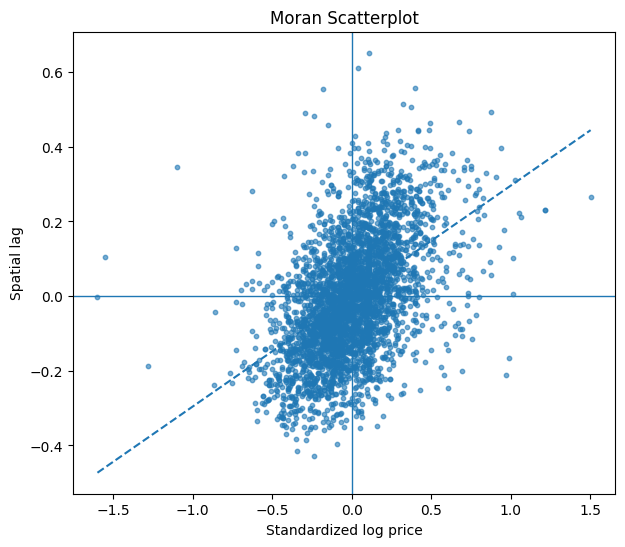

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(z_log, lag_log, s=10, alpha=0.6)

x_line = np.linspace(z_log.min(), z_log.max(), 100)
plt.plot(x_line, observed_log * x_line, linestyle="--")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Standardized log price")
plt.ylabel("Spatial lag")
plt.title("Moran Scatterplot")
plt.show()

## 9. Sensitivity to the spatial-neighborhood definition

In [9]:
rows = []

for k in [4, 8, 12, 20]:
    neighbors, distances = knn_indices(coordinates, k)
    i_price, _, _ = moran_i(price, neighbors)
    i_log, _, _ = moran_i(log_price, neighbors)

    rows.append({
        "k": k,
        "Moran_I_price": i_price,
        "Moran_I_log_price": i_log,
        "mean_neighbor_distance_km": distances.mean() * 6371.0088,
    })

sensitivity = pd.DataFrame(rows)
sensitivity

,k,Moran_I_price,Moran_I_log_price,mean_neighbor_distance_km
0,4,0.295210,0.319050,0.095469
1,8,0.276589,0.296057,0.130582
2,12,0.264274,0.285236,0.158304
3,20,0.248048,0.270699,0.202989


Positive autocorrelation remains present under all tested k-nearest-neighbor specifications, so the conclusion does not depend on one single value of `k`.

## 10. Exploratory Moran quadrants

In [10]:
cluster = np.select(
    [
        (z_log >= 0) & (lag_log >= 0),
        (z_log < 0) & (lag_log < 0),
        (z_log >= 0) & (lag_log < 0),
        (z_log < 0) & (lag_log >= 0),
    ],
    ["High-High", "Low-Low", "High-Low", "Low-High"],
    default="Other",
)

pd.Series(cluster).value_counts()

Low-Low      1318
High-High    1177
High-Low      610
Low-High      528
Name: count, dtype: int64

High-High and Low-Low observations are consistent with positive global spatial autocorrelation.

These labels are exploratory Moran quadrants. They are **not** presented as statistically significant Local Moran clusters because no local multiple-testing correction is applied here.

## 11. Conclusions

- The historical-centre sample contains more than three thousand georeferenced housing observations.
- Housing prices show meaningful positive spatial autocorrelation.
- The result is statistically significant under a 999-permutation test.
- Log prices exhibit slightly stronger global autocorrelation than raw prices.
- The conclusion remains stable across several k-nearest-neighbor weight definitions.
- Spatial dependence means ordinary models that assume independent observations may miss relevant geographic structure.

### Limitations

- KNN is one reasonable spatial-weight definition, not the only possible one.
- The analysis measures association rather than causal neighborhood effects.
- No temporal dimension is modeled.
- Exploratory quadrant labels are not significance-filtered LISA clusters.
- More advanced spatial hedonic models could explicitly incorporate spatial lag or spatial error dependence.